# 0) Enviroment

### Imports and Constants

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os

from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate, learning_curve
from sklearn.preprocessing import PolynomialFeatures, SplineTransformer, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix

from sklearn.linear_model import ElasticNet, QuantileRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.pipeline import make_pipeline
from sklearn.compose import TransformedTargetRegressor
from mord import LogisticAT


DATA_PATH = "../data/compas_preprocessed.csv"
_RS = 42
_TARGET = "decile_score"
_TEST_PERCENTAGE = 0.2


### Import data and isolate target

In [54]:
df = pd.read_csv(DATA_PATH)

y = df.pop(_TARGET)
X = df

### Helper functions


In [55]:
def get_regression_metrics(model, X_test, y_test, X_train, y_train):
    """
    Calculates and prints key regression performance metrics (MAE, MSE, RMSE and R2).
    
    Parameters:
    model: A fitted sklearn estimator or Pipeline.
    X_test: Test features (DataFrame or Array).
    y_test: True target values.
    X_train: Train features
    y_train: Train target values.
    

    Outputs:
    mae: Mean average error
    mse: Mean square error    
    rmse: Root mean square error
    r2: R2 score
    tr2: Training R2

    
    Contribution: Co-developed by Gemini Pro 3.1, mostly me.
    """
    y_pred = model.predict(X_test)

    y_train_pred = model_elastic_net.predict(X_train)
    tr2 = r2_score(y_train, y_train_pred)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    return mae, mse, rmse, r2, tr2

def print_regression_metrics(test_mae, test_mse, test_rmse, test_r2, train_r2):
    print(f"\nTraining R2: {train_r2:.4f}")
    print(f"Test R2:     {test_r2:.4f}")
    print(f"Difference:  {train_r2 - test_r2:.4f}")
    print()
    print(f"Other metrics:")
    print(f"MAE: {test_mae:.4f}")
    print(f"MSE: {test_mse:.4f}")
    print(f"RMSE: {test_rmse:.4f}")


# These 2 lines were given by Gemini, they force paralelism in GridSearch
from functools import partial
GridSearchCV = partial(GridSearchCV, n_jobs=-1)

# 1) Train and Test Split

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=_RS, test_size=_TEST_PERCENTAGE, 
    stratify=y, # To ensure we have the same percentage of decile scores in test and train data 
)

# 2) Linear Models

> **AI Acknowledgements** (Gemini):
- We found out about **Quantile** and **Ordinal** regressions while brainstorming with Gemini. They improve the model's ability to handle discrete, ranked scales and outlier-heavy data by focusing on thresholds and medians rather than just the mathematical average.

- The **TransformedTargetRegressor** is a wrapper that transforms the target variable to approximate a normal distribution in cases of skewness. Also sugested by Gemini it is useful in conjunction with the **Quantile** regression model. By stabilizing the variance and **reducing skew**, the transformation ensures the model's 'pinball loss' function is minimized across a more uniform error distribution.  

- Finally the usage of Splines to break the ~0.5 barries was also sugested by Gemini, which denoted that the linear model can be more
flexible when using them.

> **Toughts and observations:**
- The R2 score for these linear models seems to be capped at ~0.5, which leads us to believe that the dataset is more complex
and non purely linear. This is corroborated by the attempt of using **SplineTransform** to improve feature set and improving R2 score, which didn't budge, 
meaning we maxed out the capabilities of linear models for this feature set.

- While using the **TTR** we chose the np.log and np.exp to treat the right skewness of the target variable.

- TODO: calculate acc, precision and recall with rounded values. After training only.

### ElasticNet (Polinomial) 

##### Model pipeline

In [57]:
model_elastic_net_pipeline = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    StandardScaler(), # ElasticNet is very sensitive to feature scale.
    ElasticNet(
        alpha=1.0, 
        l1_ratio=0.5, 
        max_iter=10000,
        tol=0.01
    ),
)

##### Hyper Parameter Optimization

In [58]:
# The GridSearchCV was indicated by an LLM in order to optimize hyper parameters

param_grid = {
    'elasticnet__alpha': [0.01, 0.1, 1.0], 
    'elasticnet__l1_ratio': [0.5, 0.9, 0.99],
    'polynomialfeatures__degree': [1, 2]
}

model_elastic_net = GridSearchCV(
    model_elastic_net_pipeline, 
    param_grid, 
    cv=5,
    scoring='neg_mean_squared_error', 
    refit=True # Refit with best model at the end
)
model_elastic_net.fit(X_train, y_train)


print(f"Best Params: {model_elastic_net.best_params_}")

Best Params: {'elasticnet__alpha': 0.01, 'elasticnet__l1_ratio': 0.5, 'polynomialfeatures__degree': 1}


##### Baseline metrics

In [59]:
metrics = get_regression_metrics(model_elastic_net, X_test, y_test, X_train, y_train)
print_regression_metrics(*metrics)


Training R2: 0.4761
Test R2:     0.4914
Difference:  -0.0153

Other metrics:
MAE: 1.6436
MSE: 4.1009
RMSE: 2.0251


### Quantile Regression

##### Model pipeline

In [60]:
model_quantile_base_pipeline = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    StandardScaler(),
    QuantileRegressor(
        quantile=0.5,
        alpha=1.0,
        solver='highs'
    ),
)

model_quantile_pipeline = TransformedTargetRegressor(
    regressor=model_quantile_base_pipeline,
    func=np.log,
    inverse_func=np.exp
)

##### Hyper Parameter Optimization

In [61]:
param_grid_quantile = {
    'regressor__quantileregressor__quantile': [0.25, 0.5, 0.75],
    'regressor__quantileregressor__alpha': [0.01, 0.1, 1.0],
    'regressor__polynomialfeatures__degree': [1, 2]
}

model_quantile = GridSearchCV(
    model_quantile_pipeline,
    param_grid_quantile,
    cv=5,
    scoring='neg_mean_squared_error',
    refit=True
)
model_quantile.fit(X_train, y_train)

print(f"Best Params: {model_quantile.best_params_}")

Best Params: {'regressor__polynomialfeatures__degree': 2, 'regressor__quantileregressor__alpha': 0.01, 'regressor__quantileregressor__quantile': 0.5}


##### Metrics

In [62]:
metrics_quantile = get_regression_metrics(model_quantile, X_test, y_test, X_train, y_train)
print_regression_metrics(*metrics_quantile)


Training R2: 0.4761
Test R2:     0.4895
Difference:  -0.0134

Other metrics:
MAE: 1.5400
MSE: 4.1167
RMSE: 2.0290


### Ordinal Regression

##### Model pipeline

In [63]:
model_ordinal_pipeline = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    StandardScaler(),
    LogisticAT(alpha=1.0)
)

##### Hyper Parameter Optimization

In [64]:
param_grid_ordinal = {
    'logisticat__alpha': [0.01, 0.1, 1.0],
    'polynomialfeatures__degree': [1, 2]
}

model_ordinal = GridSearchCV(
    model_ordinal_pipeline,
    param_grid_ordinal,
    cv=5,
    scoring='neg_mean_squared_error',
    refit=True
)
model_ordinal.fit(X_train, y_train)

print(f"Best Params: {model_ordinal.best_params_}")

Best Params: {'logisticat__alpha': 1.0, 'polynomialfeatures__degree': 1}


##### Metrics

In [65]:
metrics_ordinal = get_regression_metrics(model_ordinal, X_test, y_test, X_train, y_train)
print_regression_metrics(*metrics_ordinal)


Training R2: 0.4761
Test R2:     0.4756
Difference:  0.0005

Other metrics:
MAE: 1.5126
MSE: 4.2283
RMSE: 2.0563


### ElasticNet (Spline + TTR)

##### Model pipeline

In [66]:
model_elasticnet_spline_base_pipeline = make_pipeline(
    SplineTransformer(n_knots=5, degree=3),
    StandardScaler(),
    ElasticNet(
        alpha=1.0,
        l1_ratio=0.5,
        max_iter=10000,
        tol=0.01
    ),
)

model_elasticnet_spline_pipeline = TransformedTargetRegressor(
    regressor=model_elasticnet_spline_base_pipeline,
    func=np.log,
    inverse_func=np.exp
)

##### Hyper Parameter Optimization

In [67]:
param_grid_elasticnet_spline = {
    'regressor__splinetransformer__n_knots': [5, 8],
    'regressor__elasticnet__alpha': [0.01, 0.1, 1.0],
    'regressor__elasticnet__l1_ratio': [0.5, 0.9, 0.99]
}

model_elasticnet_spline = GridSearchCV(
    model_elasticnet_spline_pipeline,
    param_grid_elasticnet_spline,
    cv=5,
    scoring='neg_mean_squared_error',
    refit=True
)
model_elasticnet_spline.fit(X_train, y_train)

print(f"Best Params: {model_elasticnet_spline.best_params_}")

Best Params: {'regressor__elasticnet__alpha': 0.01, 'regressor__elasticnet__l1_ratio': 0.5, 'regressor__splinetransformer__n_knots': 5}


##### Metrics

In [68]:
metrics_elasticnet_spline = get_regression_metrics(model_elasticnet_spline, X_test, y_test, X_train, y_train)
print_regression_metrics(*metrics_elasticnet_spline)


Training R2: 0.4761
Test R2:     0.4810
Difference:  -0.0049

Other metrics:
MAE: 1.5402
MSE: 4.1852
RMSE: 2.0458


# 3) Non-Linear Models

> Obversations:
- We can't seem to break 0.5 barrier, the literature points out that this is normal for human behaviour variance explainance.
Will have to review with professor

### Random forest

##### Model pipeline

In [69]:
model_random_forest_pipeline = make_pipeline(
    RandomForestRegressor(
        n_estimators=200,      
        max_features='sqrt',    # random subset of features
        random_state=_RS
    ),
)

##### Hyper parameter optimization

In [70]:
param_grid_random_forest = {
    'randomforestregressor__n_estimators': [100, 200, 300],
    'randomforestregressor__max_depth': [3, 6, 9],
    'randomforestregressor__min_samples_leaf': [1, 2, 4],
}

model_random_forest = GridSearchCV(
    estimator=model_random_forest_pipeline, 
    param_grid=param_grid_random_forest,
    cv=5, 
    scoring='neg_mean_absolute_error',
    refit=True
)

model_random_forest.fit(X_train, y_train)

print(f"Best Params: {model_random_forest.best_params_}")

Best Params: {'randomforestregressor__max_depth': 9, 'randomforestregressor__min_samples_leaf': 2, 'randomforestregressor__n_estimators': 100}


##### Metrics

In [71]:
metrics_random_forest = get_regression_metrics(model_random_forest, X_test, y_test, X_train, y_train)
print_regression_metrics(*metrics_random_forest)


Training R2: 0.4761
Test R2:     0.5017
Difference:  -0.0256

Other metrics:
MAE: 1.6046
MSE: 4.0180
RMSE: 2.0045


# 3) Classification into decile bins

##### Scoring

In [72]:
# Could do top 2 accuracy and metrics, this is, accepting a reponse beeing + or - one off as it beeing correct.
# it would increase accuracy immediatly and it would help to better visualize this rudimentary classification. 

class_model = model_elasticnet_spline

class_y_pred = np.clip(np.round(class_model.best_estimator_.predict(X_test)).astype(int), 1, 10)
class_y_true = y_test.astype(int)

class_precision = precision_score(class_y_true, class_y_pred, average='weighted', zero_division=0)
class_recall    = recall_score(class_y_true, class_y_pred, average='weighted', zero_division=0)
class_f1        = f1_score(class_y_true, class_y_pred, average='weighted', zero_division=0)
class_report    = classification_report(class_y_true, class_y_pred, zero_division=0)

print(f"Precision (weighted): {class_precision:.4f}")
print(f"Recall    (weighted): {class_recall:.4f}")
print(f"F1        (weighted): {class_f1:.4f}")
print()
print(class_report)

# I found out some models have fewer R2 but are closer to the real decile bin (ordinal is the better one at functionning as a classifier)


Precision (weighted): 0.3426
Recall    (weighted): 0.2421
F1        (weighted): 0.2525

              precision    recall  f1-score   support

           1       0.88      0.33      0.48       257
           2       0.23      0.38      0.29       165
           3       0.11      0.18      0.14       130
           4       0.21      0.32      0.26       133
           5       0.18      0.27      0.21       116
           6       0.15      0.17      0.16       106
           7       0.17      0.15      0.16        99
           8       0.21      0.11      0.14        84
           9       0.15      0.04      0.06        84
          10       0.53      0.15      0.23        61

    accuracy                           0.24      1235
   macro avg       0.28      0.21      0.21      1235
weighted avg       0.34      0.24      0.25      1235



##### Visualization

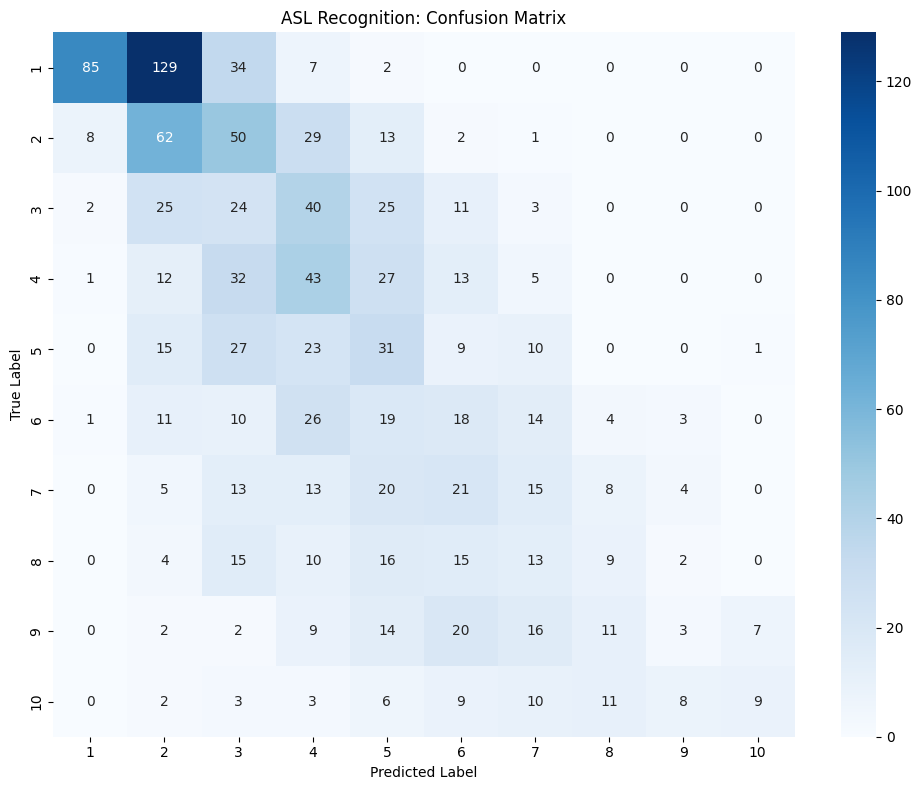

In [73]:
cm = confusion_matrix(y_test, class_y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(1,11), yticklabels=range(1,11))

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.title("ASL Recognition: Confusion Matrix")
plt.tight_layout()
plt.show()

# 4) Learning Curves

> AI Acknowledgement:
- This section was made with the help of Claude Sonnet 4.6. It helps us understand model fit and overfit trends as the data increases. 

> Thoughs and conclusions:
- Random forest achived the highest score in R2 but due to a slight overfit.

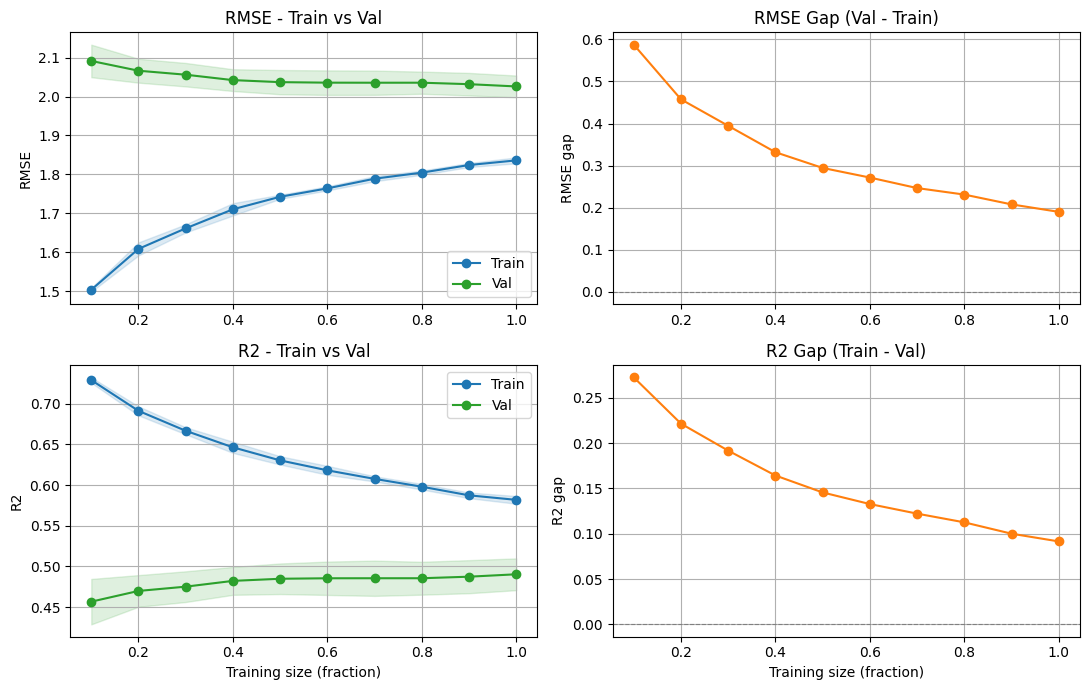

In [74]:
sizes = np.linspace(0.1, 1.0, 10)
lc_model = model_random_forest # Change here to see other models

def _lc(scoring):
    _, tr, vl = learning_curve(
        lc_model.best_estimator_, X, y,
        train_sizes=sizes, cv=5, scoring=scoring, n_jobs=-1
    )
    return tr, vl

tr_mse, vl_mse = _lc('neg_mean_squared_error')
tr_r2,  vl_r2  = _lc('r2')

tr_rmse_m, tr_rmse_s = np.sqrt(-tr_mse).mean(1), np.sqrt(-tr_mse).std(1)
vl_rmse_m, vl_rmse_s = np.sqrt(-vl_mse).mean(1), np.sqrt(-vl_mse).std(1)
tr_r2_m,   tr_r2_s   = tr_r2.mean(1),  tr_r2.std(1)
vl_r2_m,   vl_r2_s   = vl_r2.mean(1),  vl_r2.std(1)

fig, axes = plt.subplots(2, 2, figsize=(11, 7))

# RMSE - Train vs Val
ax = axes[0, 0]
ax.plot(sizes, tr_rmse_m, marker='o', label='Train', color='tab:blue')
ax.plot(sizes, vl_rmse_m, marker='o', label='Val',   color='tab:green')
ax.fill_between(sizes, tr_rmse_m - tr_rmse_s, tr_rmse_m + tr_rmse_s, alpha=0.15, color='tab:blue')
ax.fill_between(sizes, vl_rmse_m - vl_rmse_s, vl_rmse_m + vl_rmse_s, alpha=0.15, color='tab:green')
ax.set_title('RMSE - Train vs Val')
ax.set_ylabel('RMSE')
ax.legend()
ax.grid(True)

# RMSE gap
ax = axes[0, 1]
ax.plot(sizes, vl_rmse_m - tr_rmse_m, marker='o', color='tab:orange')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('RMSE Gap (Val - Train)')
ax.set_ylabel('RMSE gap')
ax.grid(True)

# R2 — Train vs Val
ax = axes[1, 0]
ax.plot(sizes, tr_r2_m, marker='o', label='Train', color='tab:blue')
ax.plot(sizes, vl_r2_m, marker='o', label='Val',   color='tab:green')
ax.fill_between(sizes, tr_r2_m - tr_r2_s, tr_r2_m + tr_r2_s, alpha=0.15, color='tab:blue')
ax.fill_between(sizes, vl_r2_m - vl_r2_s, vl_r2_m + vl_r2_s, alpha=0.15, color='tab:green')
ax.set_title('R2 - Train vs Val')
ax.set_ylabel('R2')
ax.set_xlabel('Training size (fraction)')
ax.legend()
ax.grid(True)

# R2 gap
ax = axes[1, 1]
ax.plot(sizes, tr_r2_m - vl_r2_m, marker='o', color='tab:orange')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('R2 Gap (Train - Val)')
ax.set_ylabel('R2 gap')
ax.set_xlabel('Training size (fraction)')
ax.grid(True)

plt.tight_layout()
plt.show()

# 5) Save Models

In [76]:
MODELS_DIR = "../models"
os.makedirs(MODELS_DIR, exist_ok=True)

models = {
    "elasticnet_polynomial": model_elastic_net,
    "quantile_ttr":          model_quantile,
    "ordinal":               model_ordinal,
    "elasticnet_spline_ttr": model_elasticnet_spline,
    "random_forest":         model_random_forest,
}

for name, model in models.items():
    path = os.path.join(MODELS_DIR, f"{name}.joblib")
    joblib.dump(model, path)
    print(f"Saved: {path}")

Saved: ../models/elasticnet_polynomial.joblib
Saved: ../models/quantile_ttr.joblib
Saved: ../models/ordinal.joblib
Saved: ../models/elasticnet_spline_ttr.joblib
Saved: ../models/random_forest.joblib
